# Visualizing Linear Anti-Aliasing Between Two Points

In this example we will use WxData to:

1) Download the latest Observed Sounding Data for OUN
2) Use Matplotlib to plot Temperature vs. Pressure without Linear Anti-Aliasing
3) Use `linear_anti_aliasing()` to interpolate 100 data points between each data point in the observed sounding data
4) Use Matplotlib to plot Temperature vs. Pressure with LinearAnti-Aliasing

# Imports

In [1]:
import matplotlib.pyplot as plt

from wxdata import(
    get_observed_sounding_data,
    linear_anti_aliasing
)

# Use `get_observed_sounding_data()` To Retrieve Latest OUN Sounding Data

In [2]:
df, date = get_observed_sounding_data('oun')

In [3]:
df

,PRES,HGHT,TEMP,DWPT,DRCT,SKNT,U-WIND,V-WIND,RH,THETA,BVF,WET-BULB
2,964.0,426,25.8,13.8,222.0,8.0,5.353045,5.945159,47.466561,302.098088,0.010508,17.846390
4,925.0,786,22.2,13.2,230.0,14.0,10.724622,8.999027,56.679674,302.002658,0.001246,16.291844
5,911.3,914,21.0,13.0,245.0,14.0,12.688309,5.916656,60.208563,302.060666,0.003513,15.763888
6,879.6,1219,18.1,12.5,255.0,15.0,14.488887,3.882286,69.782473,302.123455,0.003348,14.463830
7,850.0,1513,15.4,12.1,245.0,16.0,14.500925,6.761892,80.689329,302.264470,0.002513,13.270778
...,...,...,...,...,...,...,...,...,...,...,...,...
106,121.5,15240,-64.2,-87.9,275.0,55.0,54.790708,-4.793566,2.586006,381.585629,0.014198,-64.331726
107,112.0,15746,-66.9,-88.9,285.0,46.0,44.432588,-11.905676,3.120948,385.519146,0.017577,-66.999087
108,105.0,16135,-67.5,-90.5,285.0,46.0,44.432588,-11.905676,2.534900,391.551520,0.025691,-67.598046
109,104.7,16154,-67.4,-90.5,285.0,46.0,44.432588,-11.905676,2.499952,392.062295,0.026005,-67.499708


In [4]:
date

datetime.datetime(2026, 3, 4, 0, 0)

# Plot the Raw Observed Temperature vs. Pressure Data With Matplotlib

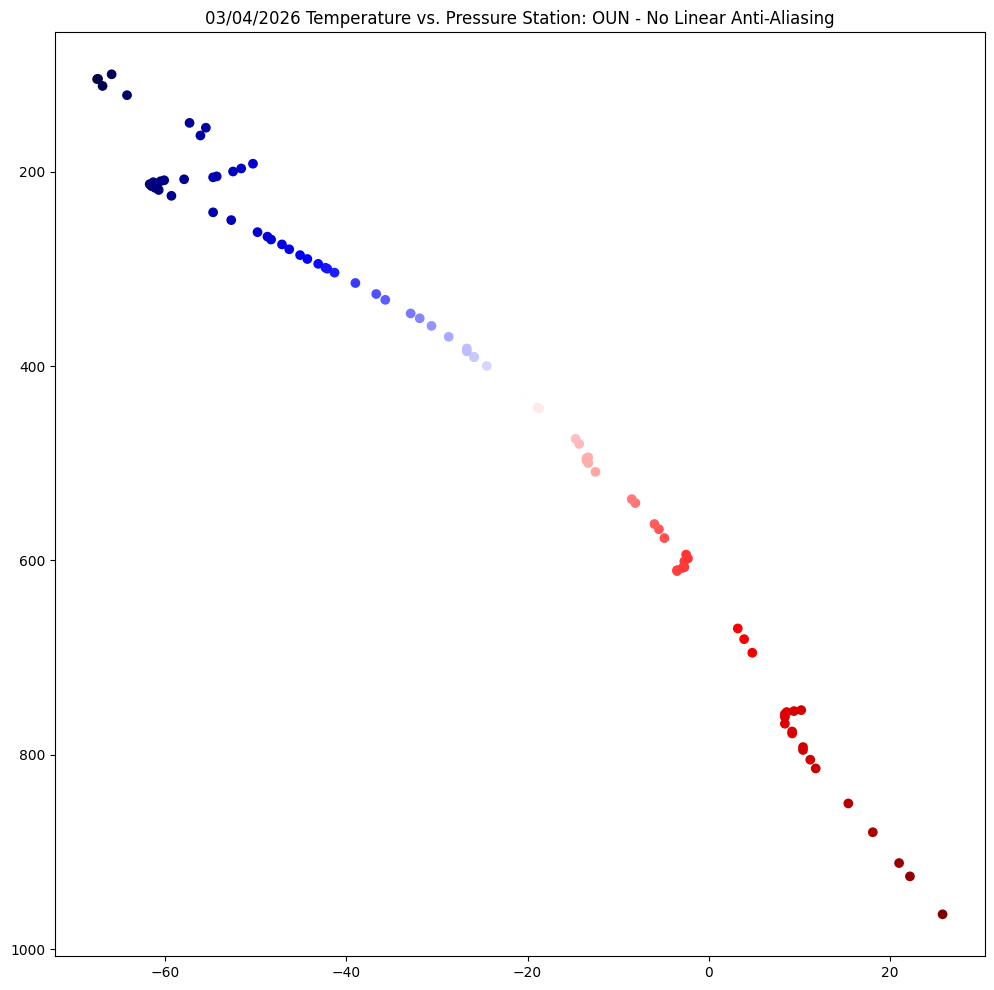

In [5]:
# Create figure object
fig = plt.figure(figsize=(12,12))

# Create out axis for our plot
ax = fig.add_subplot(1,1,1)

# Create Out Title
ax.set_title(f"{date.strftime('%m/%d/%Y')} Temperature vs. Pressure Station: OUN - No Linear Anti-Aliasing")

# Invert our y-axis
ax.invert_yaxis()

# Plot our data
ax.scatter(df['TEMP'], 
           df['PRES'], 
           c=df['TEMP'],
           cmap='seismic')

# Using `linear_anti_aliasing()` From WxData

We will now use `linear_anti_aliasing()` to interpolate 100 data points between each observed point

In [6]:
anti_aliasing = 100

temp_x, temp_y = linear_anti_aliasing(df['TEMP'], 
                                     df['HGHT'], 
                                     anti_aliasing)

In [7]:
temp_x

array([ 25.8       ,  25.76363636,  25.72727273, ..., -65.93030303,
       -65.91515152, -65.9       ], shape=(8900,))

In [8]:
temp_y

array([  426.        ,   429.63636364,   433.27272727, ...,
       16424.42424242, 16427.21212121, 16430.        ], shape=(8900,))

# Plot the Raw Observed Temperature With Linear Anti-Aliasing vs. Pressure Data With Matplotlib

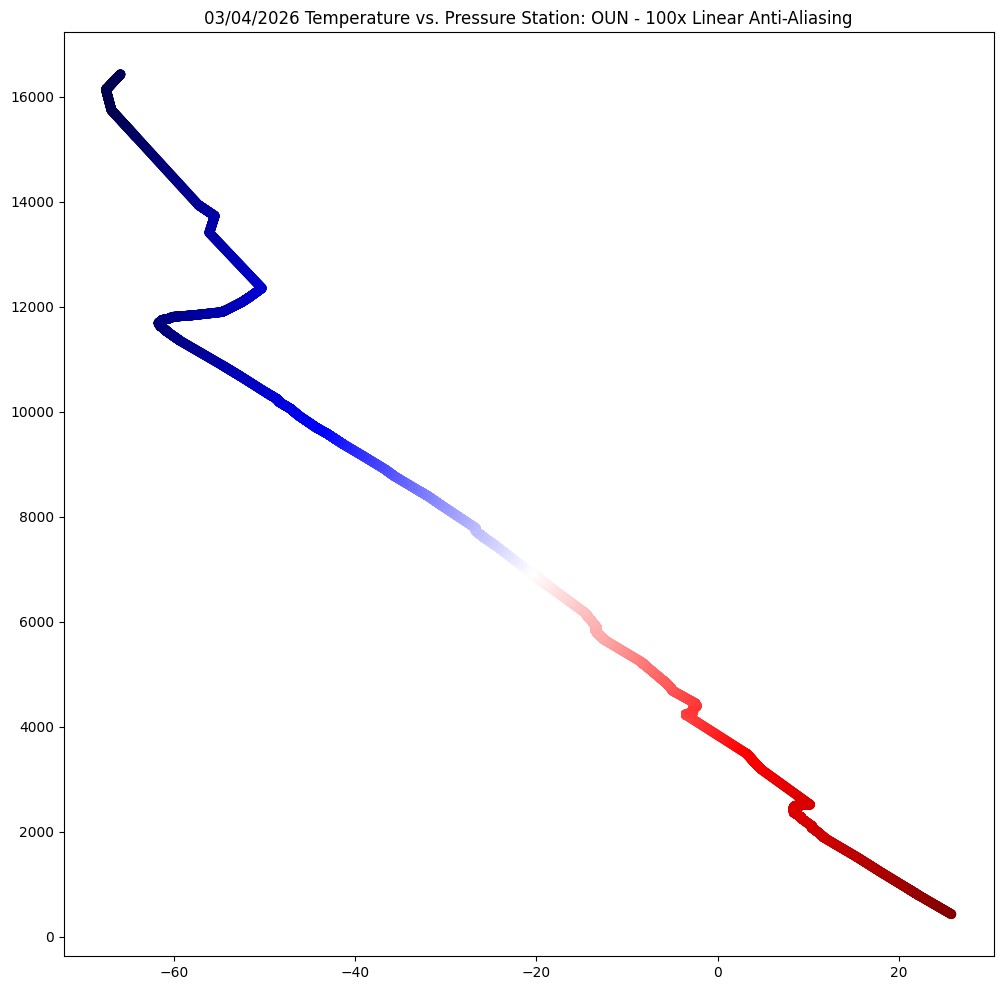

In [9]:
# Create figure object
fig = plt.figure(figsize=(12,12))

# Create out axis for our plot
ax = fig.add_subplot(1,1,1)

# Create Out Title
ax.set_title(f"{date.strftime('%m/%d/%Y')} Temperature vs. Pressure Station: OUN - 100x Linear Anti-Aliasing")

# We do not want to invert our axis this time 

# Plot our data
ax.scatter(temp_x, 
           temp_y, 
           c=temp_x,
           cmap='seismic')